In [1]:
import subprocess, sys

required = ['folium', 'scipy', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy']
for pkg in required:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All dependencies ready')

✅ All dependencies ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────

print('Loading dataset...')
df = pd.read_csv("../data/train.csv", encoding='latin1', low_memory=False)
print(f'  Raw shape : {df.shape}')

# ─────────────────────────────────────────
# CLEAN COLUMNS
# ─────────────────────────────────────────
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(f'  Columns   : {list(df.columns)}')

# Drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f'  Duplicates removed: {before - len(df)}')

# Drop rows where PdDistrict or Dates is null
df = df.dropna(subset=['dates', 'pddistrict'])

# Standardise string columns
df['category']   = df['category'].str.strip().str.upper()
df['pddistrict'] = df['pddistrict'].str.strip().str.upper()
df['dayofweek']  = df['dayofweek'].str.strip().str.title()
df['resolution'] = df['resolution'].str.strip().str.upper()

# Remove bad GPS coordinates (SF bounding box)
df = df[(df['x'].between(-123.0, -122.3)) & (df['y'].between(37.6, 37.9))]

print(f'  Clean shape: {df.shape}')
print('\n✅ Columns cleaned')

Loading dataset...
  Raw shape : (878049, 9)
  Columns   : ['dates', 'category', 'descript', 'dayofweek', 'pddistrict', 'resolution', 'address', 'x', 'y']
  Duplicates removed: 2323
  Clean shape: (875659, 9)

✅ Columns cleaned


In [3]:
import pandas as pd
# ─────────────────────────────────────────
# CONVERT DATES
# ─────────────────────────────────────────
df['dates'] = pd.to_datetime(df['dates'])

# Derived time fields
df['year']        = df['dates'].dt.year
df['month']       = df['dates'].dt.month
df['hour']        = df['dates'].dt.hour
df['date_only']   = df['dates'].dt.date
df['week_start']  = df['dates'].dt.to_period('W').apply(lambda r: r.start_time)   # Monday of the week
df['week_label']  = df['dates'].dt.strftime('W%V-%G')  # ISO week label

print('Date range:', df['dates'].min(), '→', df['dates'].max())
print('Unique years:', sorted(df['year'].unique()))
print('\n✅ Date converted')
print('✅ Ready for time-based grouping')
print('✅ Ready for anomaly detection')
df.head(3)

Date range: 2003-01-06 00:01:00 → 2015-05-13 23:53:00
Unique years: [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]

✅ Date converted
✅ Ready for time-based grouping
✅ Ready for anomaly detection


,dates,category,descript,dayofweek,pddistrict,resolution,address,x,y,year,month,hour,date_only,week_start,week_label
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,2015,5,23,2015-05-13,2015-05-11,W20-2015
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,2015,5,23,2015-05-13,2015-05-11,W20-2015
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414,2015,5,23,2015-05-13,2015-05-11,W20-2015


In [4]:
from scipy import stats

# ─────────────────────────────────────────
# WEEKLY CRIME COUNTS
# ─────────────────────────────────────────
weekly = (
    df.groupby('week_start')
    .size()
    .reset_index(name='crime_count')
    .sort_values('week_start')
    .reset_index(drop=True)
)

# ─────────────────────────────────────────
# PREVIOUS WEEK COMPARISON + % INCREASE
# ─────────────────────────────────────────
weekly['prev_week_count']  = weekly['crime_count'].shift(1)
weekly['delta']            = weekly['crime_count'] - weekly['prev_week_count']
weekly['pct_change']       = (weekly['delta'] / weekly['prev_week_count'] * 100).round(2)

# ─────────────────────────────────────────
# SPIKE DETECTION (Z-score > 2)
# ─────────────────────────────────────────
weekly['z_score']     = stats.zscore(weekly['crime_count'].fillna(0))
weekly['is_spike']    = weekly['z_score'].abs() > 2
weekly['spike_label'] = np.where(
    weekly['z_score'] > 2, '🔴 HIGH SPIKE',
    np.where(weekly['z_score'] < -2, '🔵 LOW SPIKE', '—')
)

print(f'✅ Weekly crime counts computed ({len(weekly)} weeks)')
print(f'✅ Previous week comparison done')
print(f'✅ % increase calculated')
print(f'✅ Spikes detected: {weekly["is_spike"].sum()} anomalous weeks found')
display(weekly[weekly['is_spike']].head(10)[['week_start','crime_count','prev_week_count','pct_change','z_score','spike_label']])

✅ Weekly crime counts computed (322 weeks)
✅ Previous week comparison done
✅ % increase calculated
✅ Spikes detected: 9 anomalous weeks found


,week_start,crime_count,prev_week_count,pct_change,z_score,spike_label
25,2003-12-22,2155,2548.0,-15.42,-2.541316,🔵 LOW SPIKE
103,2006-12-25,2166,2467.0,-12.20,-2.491790,🔵 LOW SPIKE
129,2007-12-24,2167,2350.0,-7.79,-2.487287,🔵 LOW SPIKE
155,2008-12-22,2185,2541.0,-14.01,-2.406244,🔵 LOW SPIKE
167,2009-06-08,2128,2430.0,-12.43,-2.662880,🔵 LOW SPIKE
180,2009-12-07,2227,2440.0,-8.73,-2.217144,🔵 LOW SPIKE
279,2013-09-30,3348,3053.0,9.66,2.830028,🔴 HIGH SPIKE
285,2013-12-23,1973,2622.0,-24.75,-3.360750,🔵 LOW SPIKE
321,2015-05-11,1117,2742.0,-59.26,-7.214790,🔵 LOW SPIKE


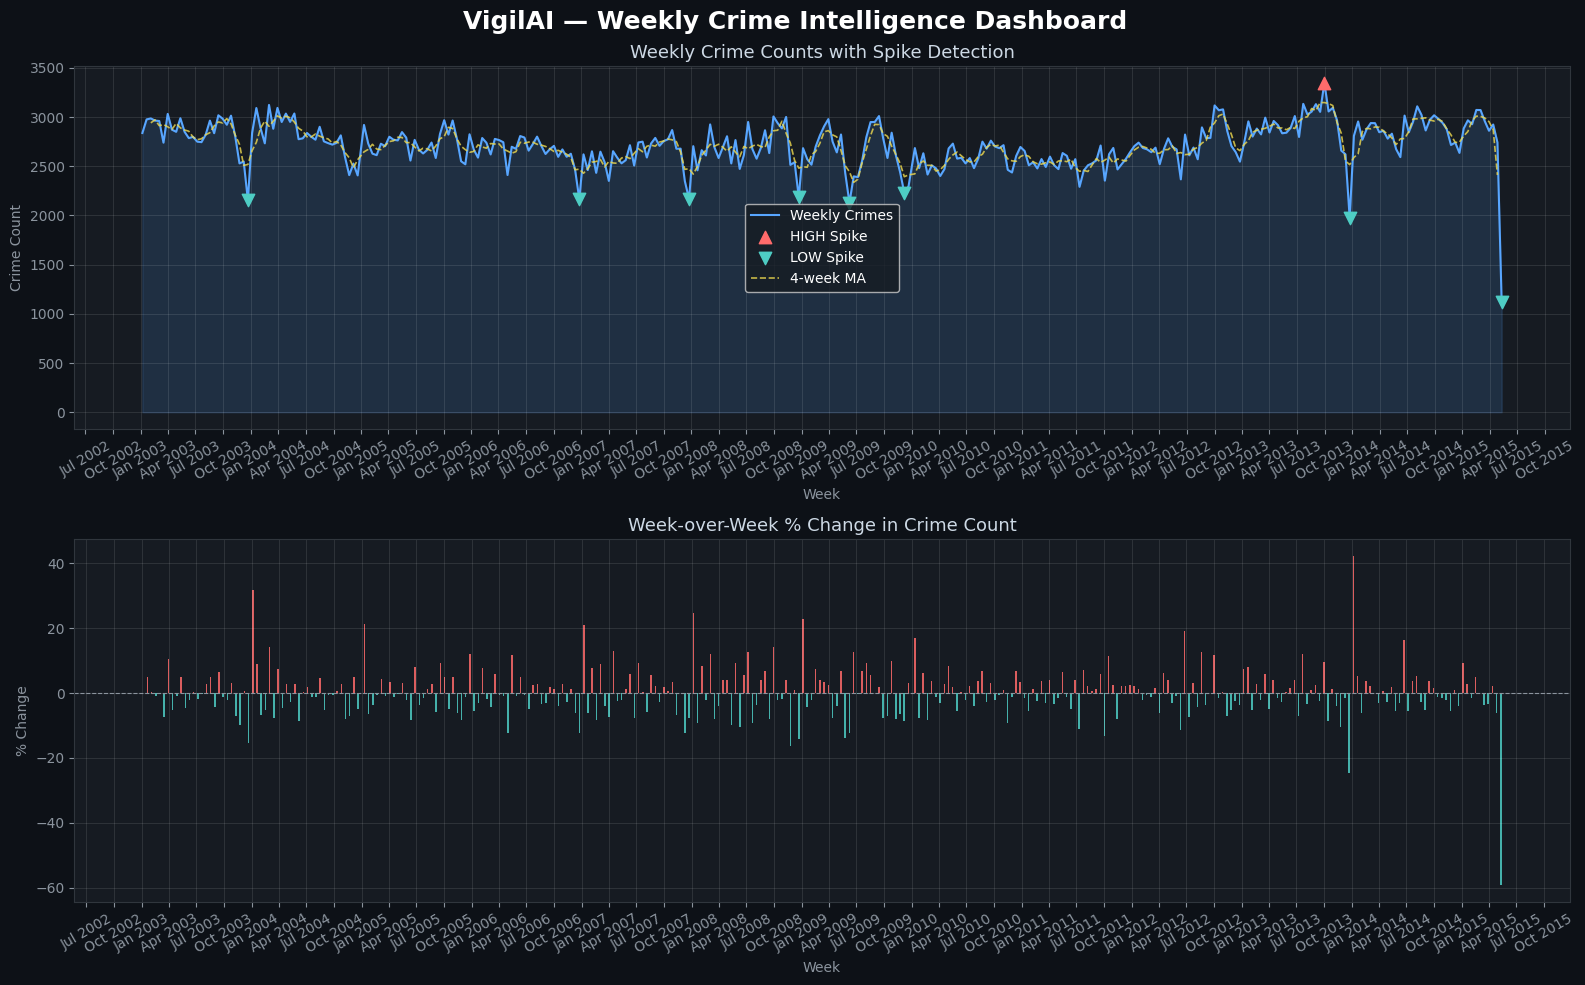

✅ Weekly crime counts | ✅ Previous week comparison | ✅ % increase | ✅ Spike detection


In [5]:
# ─────────────────────────────────────────
# VISUALISE WEEKLY TREND + SPIKES
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor='#0d1117')
fig.suptitle('VigilAI — Weekly Crime Intelligence Dashboard', 
             fontsize=18, color='white', fontweight='bold', y=0.98)

# --- Plot 1: Weekly count with spikes ---
ax1 = axes[0]
ax1.set_facecolor('#161b22')
ax1.plot(weekly['week_start'], weekly['crime_count'], 
         color='#58a6ff', linewidth=1.5, label='Weekly Crimes', zorder=2)
ax1.fill_between(weekly['week_start'], weekly['crime_count'], 
                 alpha=0.15, color='#58a6ff')

# Highlight spikes
spikes = weekly[weekly['is_spike']]
high_spikes = spikes[spikes['z_score'] > 0]
low_spikes  = spikes[spikes['z_score'] < 0]
ax1.scatter(high_spikes['week_start'], high_spikes['crime_count'], 
            color='#ff6b6b', s=80, zorder=5, label='HIGH Spike', marker='^')
ax1.scatter(low_spikes['week_start'], low_spikes['crime_count'], 
            color='#4ecdc4', s=80, zorder=5, label='LOW Spike', marker='v')

# Rolling average
rolling = weekly['crime_count'].rolling(4, center=True).mean()
ax1.plot(weekly['week_start'], rolling, '--', color='#f0db4f', 
         linewidth=1.2, alpha=0.8, label='4-week MA')

ax1.set_title('Weekly Crime Counts with Spike Detection', color='#cdd9e5', fontsize=13)
ax1.set_xlabel('Week', color='#8b949e')
ax1.set_ylabel('Crime Count', color='#8b949e')
ax1.tick_params(colors='#8b949e')
ax1.spines[:].set_color('#30363d')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
ax1.legend(facecolor='#161b22', labelcolor='white', framealpha=0.8)
ax1.grid(True, alpha=0.1, color='white')

# --- Plot 2: % Change week-over-week ---
ax2 = axes[1]
ax2.set_facecolor('#161b22')
colors = ['#ff6b6b' if v > 0 else '#4ecdc4' for v in weekly['pct_change'].fillna(0)]
ax2.bar(weekly['week_start'], weekly['pct_change'].fillna(0), 
        color=colors, width=5, alpha=0.85)
ax2.axhline(0, color='#8b949e', linewidth=0.8, linestyle='--')
ax2.set_title('Week-over-Week % Change in Crime Count', color='#cdd9e5', fontsize=13)
ax2.set_xlabel('Week', color='#8b949e')
ax2.set_ylabel('% Change', color='#8b949e')
ax2.tick_params(colors='#8b949e')
ax2.spines[:].set_color('#30363d')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
ax2.grid(True, alpha=0.1, color='white')

plt.tight_layout()
plt.savefig('../weekly_crime_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Weekly crime counts | ✅ Previous week comparison | ✅ % increase | ✅ Spike detection')

In [6]:
# ─────────────────────────────────────────
# RANK DISTRICTS BY TOTAL CRIME
# ─────────────────────────────────────────
district_stats = (
    df.groupby('pddistrict')
    .agg(
        total_crimes   = ('category', 'count'),
        unique_cats    = ('category', 'nunique'),
        lat            = ('y', 'mean'),
        lon            = ('x', 'mean'),
    )
    .reset_index()
    .sort_values('total_crimes', ascending=False)
    .reset_index(drop=True)
)

district_stats['rank'] = district_stats['total_crimes'].rank(ascending=False).astype(int)
district_stats['pct_of_total'] = (district_stats['total_crimes'] / district_stats['total_crimes'].sum() * 100).round(2)

print('✅ Districts ranked by crime count:')
display(district_stats[['rank','pddistrict','total_crimes','pct_of_total','unique_cats']])

✅ Districts ranked by crime count:


,rank,pddistrict,total_crimes,pct_of_total,unique_cats
0,1,SOUTHERN,156520,17.87,38
1,2,MISSION,119722,13.67,39
2,3,NORTHERN,105093,12.00,39
3,4,BAYVIEW,89089,10.17,39
4,5,CENTRAL,85262,9.74,39
5,6,TENDERLOIN,81627,9.32,38
6,7,INGLESIDE,78718,8.99,37
7,8,TARAVAL,65396,7.47,38
8,9,PARK,49159,5.61,37
9,10,RICHMOND,45073,5.15,38


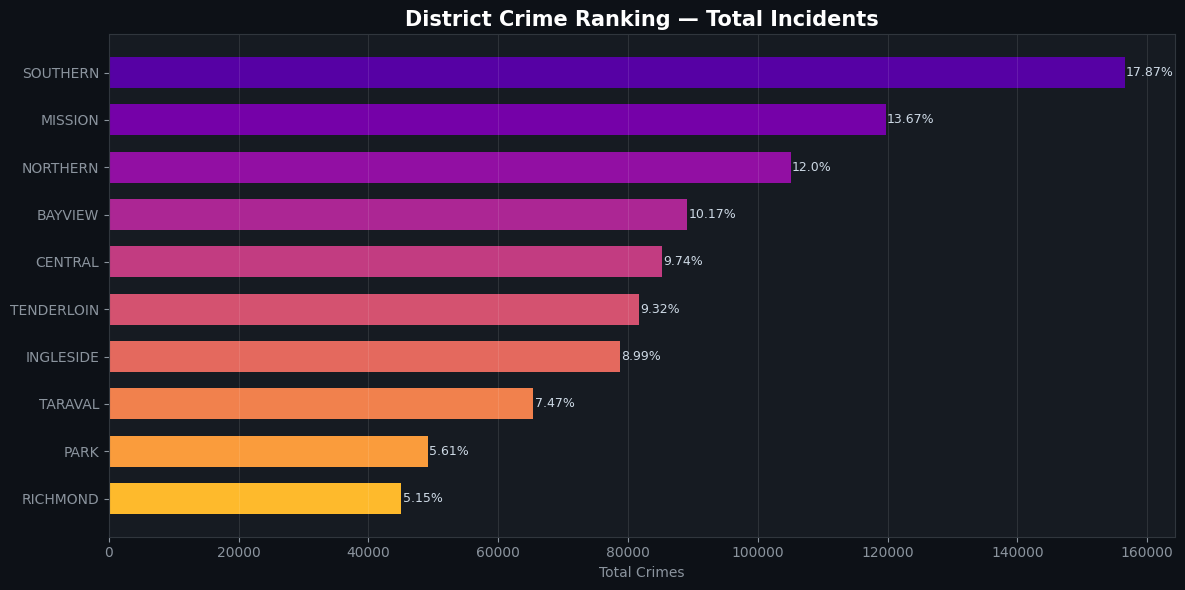

✅ District ranking visualised


In [7]:
# ─────────────────────────────────────────
# BAR CHART — DISTRICT RANKING
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')

palette = plt.cm.plasma(np.linspace(0.85, 0.15, len(district_stats)))
bars = ax.barh(district_stats['pddistrict'][::-1], 
               district_stats['total_crimes'][::-1],
               color=palette, edgecolor='none', height=0.65)

for bar, pct in zip(bars, district_stats['pct_of_total'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', color='#cdd9e5', fontsize=9)

ax.set_title('District Crime Ranking — Total Incidents', 
             color='white', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Crimes', color='#8b949e')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')
ax.grid(True, axis='x', alpha=0.1, color='white')
plt.tight_layout()
plt.savefig('../notebooks/district_ranking.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ District ranking visualised')

In [8]:
import folium

# ─────────────────────────────────────────
# INTERACTIVE MAP — CIRCLE SIZE = CRIME COUNT
# ─────────────────────────────────────────
MAX_RADIUS = 35   # Max circle radius in pixels
MIN_RADIUS = 8

max_crimes = district_stats['total_crimes'].max()
min_crimes = district_stats['total_crimes'].min()

def scale_radius(count, lo=min_crimes, hi=max_crimes, rlo=MIN_RADIUS, rhi=MAX_RADIUS):
    '''Linearly scale count → radius in [rlo, rhi].'''
    return rlo + (count - lo) / (hi - lo) * (rhi - rlo)

def rank_to_color(rank, n=len(district_stats)):
    '''Red→Yellow→Green gradient by rank.'''
    ratio = 1 - (rank - 1) / (n - 1)   # 1 = highest crime (red)
    r = int(255 * ratio)
    g = int(255 * (1 - ratio))
    return f'#{r:02x}{g:02x}40'

sf_map = folium.Map(location=[37.77, -122.42], zoom_start=12, 
                    tiles='CartoDB dark_matter')

for _, row in district_stats.iterrows():
    radius   = scale_radius(row['total_crimes'])
    color    = rank_to_color(row['rank'])
    popup_html = (
        f"<div style='font-family:monospace; background:#0d1117; color:#cdd9e5; "
        f"padding:8px; border-radius:6px; min-width:160px;'>"
        f"<b style='color:#58a6ff'>#{row['rank']} {row['pddistrict']}</b><br>"
        f"Total crimes: <b style='color:#ff6b6b'>{row['total_crimes']:,}</b><br>"
        f"Share: {row['pct_of_total']}%<br>"
        f"Crime types: {row['unique_cats']}</div>"
    )
    folium.CircleMarker(
        location   = [row['lat'], row['lon']],
        radius     = radius,
        color      = color,
        fill       = True,
        fill_color = color,
        fill_opacity = 0.65,
        popup      = folium.Popup(popup_html, max_width=220),
        tooltip    = f"{row['pddistrict']}: {row['total_crimes']:,} crimes (Rank #{row['rank']})"
    ).add_to(sf_map)

# Title overlay
title_html = '''
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index:9999; background: rgba(13,17,23,0.92); color: white; padding: 10px 20px;
     border-radius: 8px; font-family:sans-serif; font-size:15px; font-weight:bold;
     border: 1px solid #30363d;">
     🕷️ VigilAI — District Crime Map (circle size = crime volume)
</div>'''
sf_map.get_root().html.add_child(folium.Element(title_html))

map_path = '../notebooks/vigilai_district_map.html'
sf_map.save(map_path)
print(f'✅ Map saved → {map_path}')
print('✅ Circle size controlled by crime count')
print('✅ District ranking embedded in map tooltips')
sf_map

✅ Map saved → ../notebooks/vigilai_district_map.html
✅ Circle size controlled by crime count
✅ District ranking embedded in map tooltips
